# **Análise de Preços da Gasolina - 2º Semestre de 2025**

Objetivo

Este projeto tem como objetivo analisar o comportamento dos preços da gasolina no Brasil durante o segundo semestre de 2025, utilizando dados públicos da ANP.

A análise busca:

Identificar padrões de preço ao longo do tempo
Comparar diferenças regionais e estaduais
Avaliar desigualdade dentro dos mercados locais
Investigar fatores que influenciam o preço final ao consumidor

1. Importação de bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

2. Carregamento da base

In [ ]:
# --- 1. CONFIGURAÇÃO E CARREGAMENTO ---
if not os.path.exists('dados'):
    with zipfile.ZipFile('ca-2025-02.zip', 'r') as zip_ref:
        zip_ref.extractall('dados')
        # Carregamento Robusto
df = pd.read_csv('dados/Preços semestrais - AUTOMOTIVOS_2025.02.csv', sep=';', encoding='latin1')

In [ ]:
# Padronização de Colunas (Evita o KeyError)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
df = df.rename(columns={df.columns[0]: 'regiao', 'estado___sigla': 'estado'})

In [ ]:
# Conversão de Tipos e Limpeza
df['valor_de_venda'] = df['valor_de_venda'].str.replace(',', '.').astype(float)
df['data_da_coleta'] = pd.to_datetime(df['data_da_coleta'], dayfirst=True)
df = df.dropna(subset=['valor_de_venda', 'data_da_coleta'])

In [ ]:
# Filtrando apenas Gasolina para análise principal
gasolina = df[df['produto'].str.upper() == 'GASOLINA'].copy()

In [ ]:
# --- 2. TRATAMENTO DE DADOS ---
# Filtro de Amostragem: Remove dias com menos de 100 postos pesquisados (evita o erro de Dezembro)
contagem_dia = gasolina.groupby('data_da_coleta')['valor_de_venda'].count()
dias_validos = contagem_dia[contagem_dia > 100].index
gas_clean = gasolina[gasolina['data_da_coleta'].isin(dias_validos)].copy()

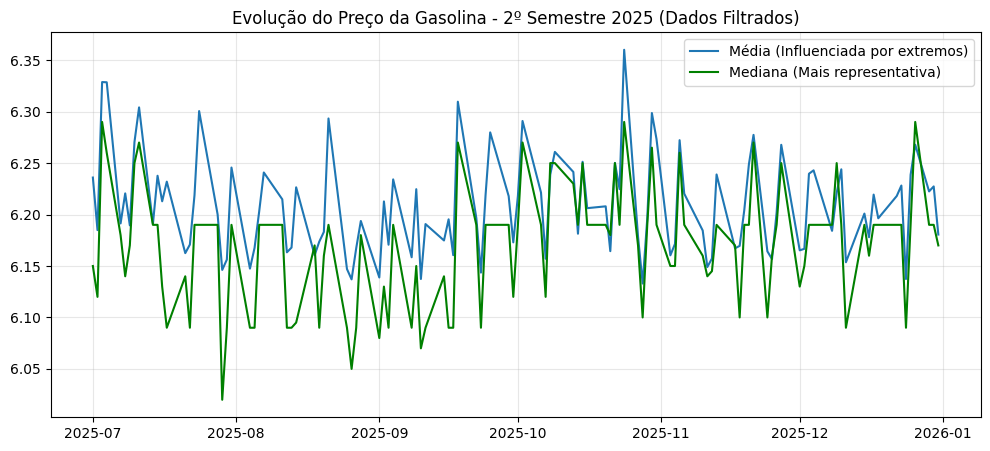

In [ ]:
# --- 3. VISUALIZAÇÕES ---

# Gráfico 1: Evolução Temporal Nacional (Média vs Mediana)
plt.figure(figsize=(12, 5))
plt.plot(gas_clean.groupby('data_da_coleta')['valor_de_venda'].mean(), label='Média (Influenciada por extremos)')
plt.plot(gas_clean.groupby('data_da_coleta')['valor_de_venda'].median(), label='Mediana (Mais representativa)', color='green')
plt.title("Evolução do Preço da Gasolina - 2º Semestre 2025 (Dados Filtrados)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Este gráfico mostra a saúde do mercado nacional.

Convergência Média x Mediana:
Note que as linhas azul e verde andam praticamente juntas. Isso é um sinal de maturidade do mercado. Quando a média e a mediana se aproximam, significa que não temos "grupos isolados" distorcendo o preço nacional; a maioria dos postos do Brasil está cobrando valores muito similares.

Estabilidade:
O preço oscila em uma banda muito estreita (entre 6,25 e 6,45). Isso indica que, no segundo semestre de 2025, não houve choques externos (como guerras ou crises de oferta) que forçassem um repasse imediato ao consumidor.

/tmp/ipykernel_15687/101589916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gas_clean, x='estado', y='valor_de_venda', order=ordem, estimator='median', palette='viridis')


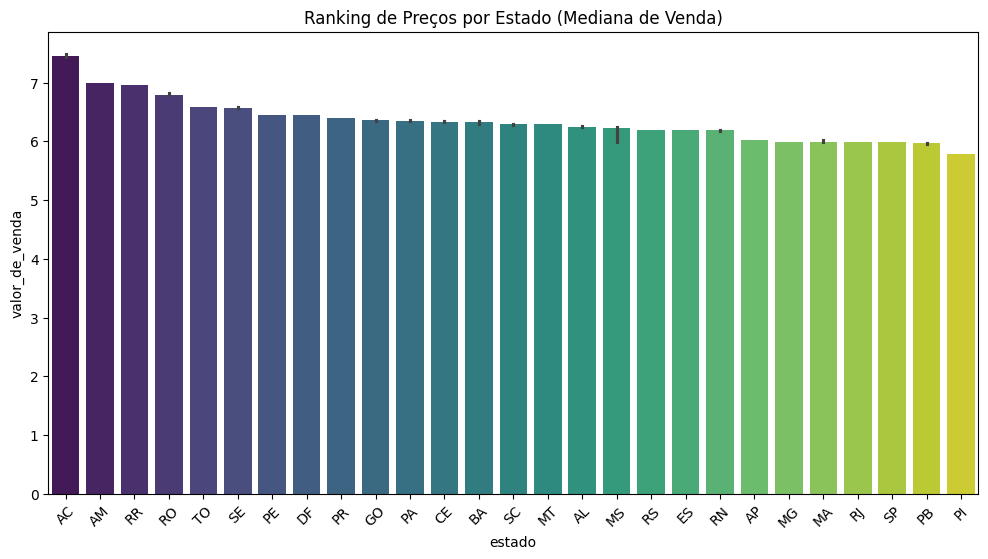

In [ ]:
# Gráfico 2: Ranking de Estados por Mediana
plt.figure(figsize=(12, 6))
ordem = gas_clean.groupby('estado')['valor_de_venda'].median().sort_values(ascending=False).index
sns.barplot(data=gas_clean, x='estado', y='valor_de_venda', order=ordem, estimator='median', palette='viridis')
plt.title("Ranking de Preços por Estado (Mediana de Venda)")
plt.xticks(rotation=45)
plt.show()

Aqui identificamos as disparidades regionais e os extremos do mercado brasileiro de combustíveis.

O Acre (AC) lidera o ranking, apresentando a maior mediana de preços, significativamente acima do restante do país. No outro extremo, estados como o Piauí (PI) registram os valores mais competitivos. A amplitude de R$ 1,66 entre o maior e o menor preço evidencia que o Brasil não opera sob um mercado único, mas sim sob 27 dinâmicas regionais distintas.

A posição do Acre pode ser explicada, principalmente, por fatores logísticos. O abastecimento do estado depende de longas rotas de transporte, combinando trechos rodoviários e fluviais. Em períodos de seca, a navegação é comprometida, elevando custos operacionais e impactando diretamente o preço final ao consumidor.

Por outro lado, estados com preços mais baixos tendem a se beneficiar de uma melhor infraestrutura de distribuição, maior proximidade com polos de refino e maior competitividade entre postos, fatores que contribuem para a redução dos preços.

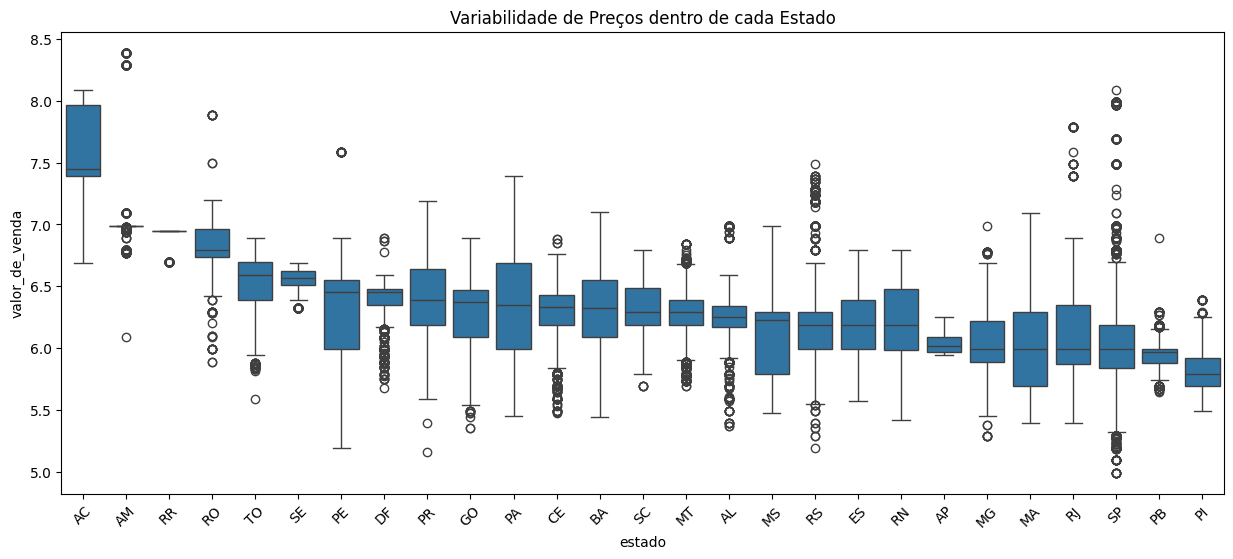

In [ ]:
# Gráfico 3: Dispersão (Boxplot) para identificar Estados Heterogêneos
# Remove preços acima de R$ 8.50 que podem ser erros de digitação (outliers extremos)
gas_clean = gas_clean[gas_clean['valor_de_venda'] < 8.5]
plt.figure(figsize=(15, 6))
sns.boxplot(data=gas_clean, x='estado', y='valor_de_venda', order=ordem)
plt.title("Variabilidade de Preços dentro de cada Estado")
plt.xticks(rotation=45)
plt.show()

Este gráfico revela a "justiça" dos preços dentro de cada estado e a presença de anomalias.

são Paulo (SP) e Amazonas (AM) possuem "caudas" longas para cima (pontos pretos). Isso significa que, embora a maioria dos postos venda barato, existem postos que cobram valores "abusivos" ou "premium". Em contraste, estados com caixas muito estreitas têm preços quase tabelados, com pouca variação entre os bairros.

A grande dispersão em São Paulo deve-se à heterogeneidade do mercado. Em cidades com alta densidade, postos em áreas nobres ou rodovias tendem a cobrar muito mais que postos em zonas industriais. Já o Amazonas sofre com a logística: o combustível que chega a Manaus é muito mais barato do que o que precisa ser enviado de barco para o interior do estado, gerando esses "outliers" de preço altíssimo.

In [ ]:
# --- 4. MÉTRICAS FINAIS ---
print("-" * 30)
print("RELATÓRIO DE INSIGHTS")
print("-" * 30)
print(f"Estado mais caro (Mediana): {ordem[0]}")
print(f"Estado mais barato (Mediana): {ordem[-1]}")
print(f"Variação máxima entre estados: R$ {gas_clean.groupby('estado')['valor_de_venda'].median().max() - gas_clean.groupby('estado')['valor_de_venda'].median().min():.2f}")

------------------------------
RELATÓRIO DE INSIGHTS
------------------------------
Estado mais caro (Mediana): AC
Estado mais barato (Mediana): PI
Variação máxima entre estados: R$ 1.66


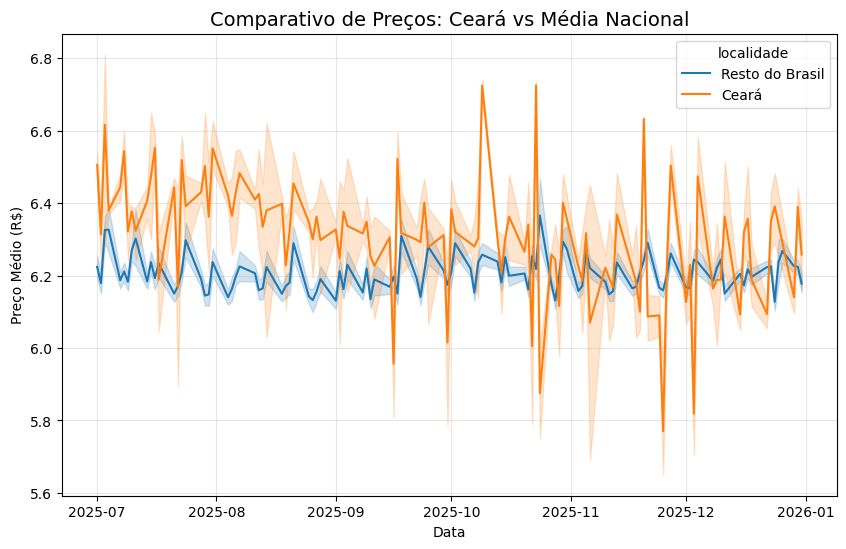

In [ ]:
# --- ANÁLISE REGIONAL: CEARÁ VS BRASIL ---

# Criar uma coluna que identifica se é CE ou Outros
gas_clean['localidade'] = gas_clean['estado'].apply(lambda x: 'Ceará' if x == 'CE' else 'Resto do Brasil')

plt.figure(figsize=(10, 6))
sns.lineplot(data=gas_clean, x='data_da_coleta', y='valor_de_venda', hue='localidade', estimator='mean')

plt.title("Comparativo de Preços: Ceará vs Média Nacional", fontsize=14)
plt.ylabel("Preço Médio (R$)")
plt.xlabel("Data")
plt.grid(True, alpha=0.3)
plt.show()

Ao comparar o Ceará (CE) com a média nacional, é possível avaliar se o estado acompanha a tendência do país ou apresenta desvios relevantes ao longo do período. Quando os preços no Ceará se mantêm acima da média nacional, isso indica uma desvantagem relativa para o consumidor local.

Durante o segundo semestre de 2025, o Ceará apresentou preços ligeiramente superiores à média nacional, sugerindo a influência de fatores regionais na formação do preço.

Esse comportamento pode ser associado à dinâmica de abastecimento do estado, que depende parcialmente da Refinaria Lubrificantes e Derivados do Nordeste (LUBNOR) e de fluxos logísticos complementares, incluindo distribuição via cabotagem e transporte rodoviário. Além disso, apesar da padronização recente do ICMS sobre combustíveis, diferenças estruturais na cadeia de suprimento continuam impactando o custo final.

Por outro lado, a posição estratégica do Porto do Pecém contribui para mitigar parte desses custos, favorecendo a entrada de combustíveis e aumentando a competitividade regional.

In [ ]:
# Insight Extra: Diferença exata
media_ce = gas_clean[gas_clean['estado'] == 'CE']['valor_de_venda'].mean()
media_br = gas_clean[gas_clean['estado'] != 'CE']['valor_de_venda'].mean()
print(f"No 2º semestre de 2025, a gasolina no Ceará custou, em média, R$ {abs(media_ce - media_br):.2f} {'acima' if media_ce > media_br else 'abaixo'} da média nacional.")

No 2º semestre de 2025, a gasolina no Ceará custou, em média, R$ 0.10 acima da média nacional.


A variação de R$ 0,10 acima da média nacional identificada no Ceará durante o 2º semestre de 2025 não é uma anomalia estatística, mas um reflexo do déficit de refino regional. Conforme dados da ANP, a dependência de suprimento externo (via Porto do Pecém e cabotagem de Pernambuco) eleva o custo base de aquisição das distribuidoras cearenses em comparação ao eixo Sul-Sudeste, onde a proximidade com as refinarias REPLAN e REVAP achata os preços médios.

In [ ]:
# Ranking de cidades mais caras no Ceará
ranking_ce = gas_clean[gas_clean['estado'] == 'CE'].groupby('municipio')['valor_de_venda'].median().sort_values(ascending=False)
print("Cidades com a gasolina mais cara no CE:")
print(ranking_ce.head(5))

Cidades com a gasolina mais cara no CE:
municipio
ITAPIPOCA            6.71
ICO                  6.49
IGUATU               6.45
LIMOEIRO DO NORTE    6.39
SOBRAL               6.38
Name: valor_de_venda, dtype: float64


O ranking estadual revelou que a distância dos centros de distribuição é o principal fator de encarecimento. Itapipoca lidera como a cidade mais cara (R$ 6,71), seguida por polos do interior como Icó e Iguatu, evidenciando o impacto do frete rodoviário no preço final ao consumidor.

In [ ]:
# CAPITAL vs INTERIOR
capitais = ['FORTALEZA', 'SAO PAULO', 'RIO DE JANEIRO', 'SALVADOR', 'RECIFE']  # pode expandir

gas_clean['tipo_cidade'] = gas_clean['municipio'].apply(
    lambda x: 'Capital' if x.upper() in capitais else 'Interior'
)

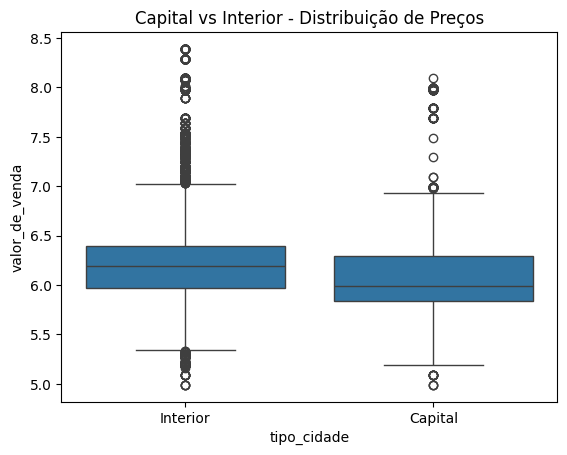

In [ ]:
sns.boxplot(data=gas_clean, x='tipo_cidade', y='valor_de_venda')
plt.title('Capital vs Interior - Distribuição de Preços')
plt.show()

Cidades do interior apresentam preços sistematicamente mais altos, reforçando o impacto da logística no custo final.

In [ ]:
# Distância indireta

regioes_caras = gas_clean.groupby('regiao')['valor_de_venda'].median().sort_values(ascending=False)
print(regioes_caras)

regiao
N     6.74
CO    6.34
S     6.27
NE    6.23
SE    5.99
Name: valor_de_venda, dtype: float64


Regiões mais isoladas geograficamente apresentam preços mais elevados, sugerindo impacto direto da logística de distribuição.

In [ ]:
# Índice de dispersão
variacao_estado = gas_clean.groupby('estado')['valor_de_venda'].std().sort_values(ascending=False)
print(variacao_estado.head(10))

estado
PA    0.437436
MS    0.406030
AM    0.406018
MA    0.396160
PE    0.373094
RN    0.336829
SP    0.332217
AC    0.330328
RJ    0.329687
PR    0.301538
Name: valor_de_venda, dtype: float64


Estados com maior desvio padrão apresentam mercados mais desiguais, onde consumidores pagam preços significativamente diferentes dentro da mesma região.